# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Tamara Balvin
* Username: tbalvin
* Student number: S6217451
* Group (AS1, etc.): AS1

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

In [2]:
import math, numpy as np

#given data
L = 1
errorL = 0.01
T = 2.01
errorT = 0.02

#gravitational acceleration formula
g = (4*math.pi**2*L)/T**2

#Taylor expansion
#partial derivatives
g_L = (4*math.pi**2)/T**2
g_T = (-8*math.pi**2*L)/T**3

#error
errorg = ((g_L**2)*(errorL**2) + (g_T**2)*(errorT**2))**(1/2)

print(f'Using the Taylor expansion:')
print(f'g = {g:.2f}')
print(f'error of g = {errorg:.2f}')
print()

#Monte Carlo error propagation
#arrays of random data points
arrayL = np.random.normal(1,0.1,100000)
arrayT = np.random.normal(2.01,0.02,100000)

arrayG = (4*(math.pi**2)*arrayL)/arrayT**2   #formula for g but using arrays
g = np.mean(arrayG)   #average value for g
errorg = np.std(arrayG)   #standard deviation = error for g

print(f'Using the Monte Carlo error propagation:')
print(f'g = {g:.2f}')
print(f'error of g = {errorg:.2f}')

#The error values are quite different: the Taylor approximation neglects higher order terms, giving a less accurate error value.

Using the Taylor expansion:
g = 9.77
error of g = 0.22

Using the Monte Carlo error propagation:
g = 9.77
error of g = 1.00


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [1]:
a = int(input('a = '))
b = int(input('b = '))
c = int(input('c = '))

D = b**2 - 4*a*c   #discriminant
x1 = ((-b)+D**(1/2))/(2*a)   #roots
x2 = ((-b)-D**(1/2))/(2*a)   #python automatically deals with complex numbers, if the discriminant is negative, python will turn x1 and x2 into complex numbers on its own

check1 = a*x1**2 + b*x1 + c
check2 = a*x2**2 + b*x2 + c   #calculates quadratic equation using found roots to show f(x) = 0

print(f'y = {a}*x^2 + {b}*x + {c}')
print(f'the roots of this equation are x1 = {x1:.2f} and x2 = {x2:.2f}.')
print(f'{a}*({x1:.2f})^2 + {b}*({x1:.2f}) + {c} = {check1:.2f}')
print(f'{a}*({x2:.2f})^2 + {b}*({x2:.2f}) + {c} = {check2:.2f}')

a = 1
b = 2
c = 3
y = 1*x^2 + 2*x + 3
the roots of this equation are x1 = -1.00+1.41j and x2 = -1.00-1.41j.
1*(-1.00+1.41j)^2 + 2*(-1.00+1.41j) + 3 = -0.00+0.00j
1*(-1.00-1.41j)^2 + 2*(-1.00-1.41j) + 3 = -0.00+0.00j


In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

In [ ]:
import numpy as np, matplotlib.pyplot as plt, scipy, math

def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

A = 1.0
x0 = 0.0
sig = 2.0
z0 = 0.0

x = np.linspace(-10,10,200)   #samples
y = gauss(x, A, x0, sig, z0)

plt.scatter(x,y)

#first area
area1 = scipy.integrate.quad(gauss, 0, 2.5, args=(A,x0,sig,z0))
print(f'Area between x=0 and x=2.5: {area1[0]}')
print()

plt.fill_between(x,y,0,color='seagreen',alpha=0.5)

#second area
area2 = scipy.integrate.quad(gauss, -np.inf, np.inf, args=(A,x0,sig,z0))
print(f'Area between -inf and inf: {area2[0]}')
print()

#proving total area is the same using two methods
total_area_check = A*sig*(2*math.pi)**(1/2)
print(f'Total area using two methods: {area2[0]} = {total_area_check}')

plt.show()

In [ ]:
#executable script gaussarea

import numpy as np, matplotlib.pyplot as plt, scipy

def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

A = int(input('A = '))
x0 = int(input('x0 = '))
sigma = int(input('sigma = '))
z0 = int(input('z0 = '))
min_lim = int(input('Lower integration limit = '))
max_lim = int(input('Upper integration limit = '))

area = scipy.integrate.quad(gauss, min_lim, max_lim, args=(A,x0,sigma,z0))

x = np.linspace(-10,10,200)
y = gauss(x, A, x0, sigma, z0)

plt.scatter(x,y)
plt.fill_between(x, y, 0, color='seagreen', alpha=0.5, label=f'Integration area = {area[0]:.2f}')
plt.legend()
plt.show()

generated example

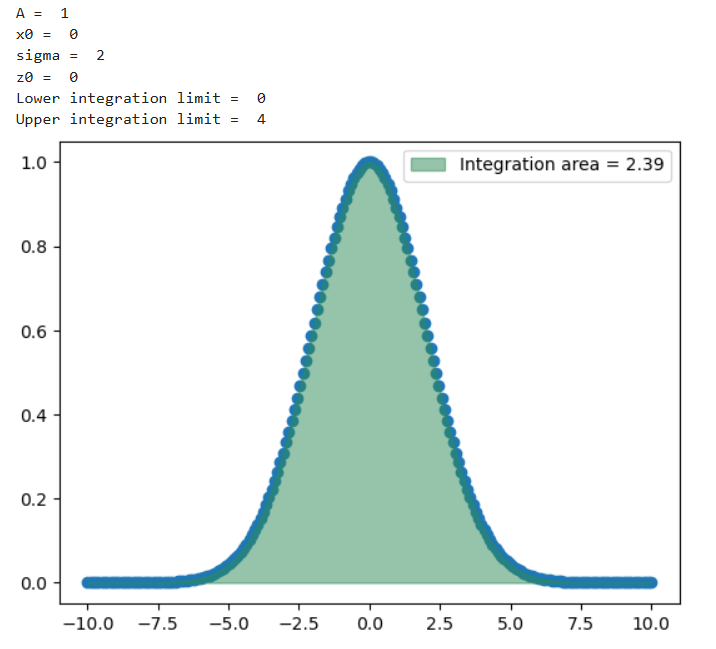

github: https://github.com/tamarabalvin-dev/PROGNUM-repo.git
in Task4

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [ ]:
import numpy as np
from numpy import sin, cos, exp, pi
import scipy

inp = input('Input function: f(x) =')   #user input

def function(x):
#returns evaluated function from user input, in case of an error raises error message
    try:
        return np.ones_like(x) * eval(inp)   #np.ones_like(x) returns array for Monte Carlo method (needed when input is a scalar)
    except:
        raise NameError 

#quad() integration
try:
    integral1 = scipy.integrate.quad(function,0,pi)
except NameError:
    print(f'Invalid function, cannot perform integration using function quad().')   #prints error for a function the code cannot evaluate
else:
    print(f'Integration using the quad() function: {integral1[0]:.3f}')

#Monte Carlo integration
a = 0
b = pi
N = 100000   #customizable variables
x_array = np.random.uniform(a,b,N)   #values of x to "integrate"
try:
    integral2 = ((b-a)/N)*np.sum(function(x_array))   #Monte Carlo method
except NameError:
    print(f'Invalid function, cannot perform integration using Monte Carlo.')   #same as for the quad() method
else:
    print(f'Integration using Monte Carlo: {integral2:.3f}')

In [ ]:
from sympy import integrate, symbols, sin, cos, exp, pi

x = symbols('x')
expr = x**4 + exp(sin(x)+cos(x))   #function to integrate
integral = integrate(expr,(x,0,pi)).evalf()   #function given in instructions had to be evaluated numerically using .evalf(), symbolic integration is nontrivial
print(f'Integration using SymPy: {integral:.3f}')

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

[(1.2985312 , 0.00952245, 12.2209, 12.65  , 11.6189, 0, 0, 221.82442 )
 (1.3863556 , 0.0175672 , 12.2759, 12.8311, 11.5693, 0, 0, 294.87552 )
 (0.21555786, 0.0213323 , 14.8859, 15.9424, 13.8723, 0, 0, 137.3204  ) ...
 (0.28765953, 0.0124601 , 13.6991, 14.425 , 12.8661, 0, 0, 161.29176 )
 (0.4197104 , 0.0149697 , 11.94  , 12.7368, 11.0688, 0, 0, 444.34464 )
 (0.20733567, 0.0219631 , 14.7777, 15.5522, 13.9136, 0, 0,  94.565956)]


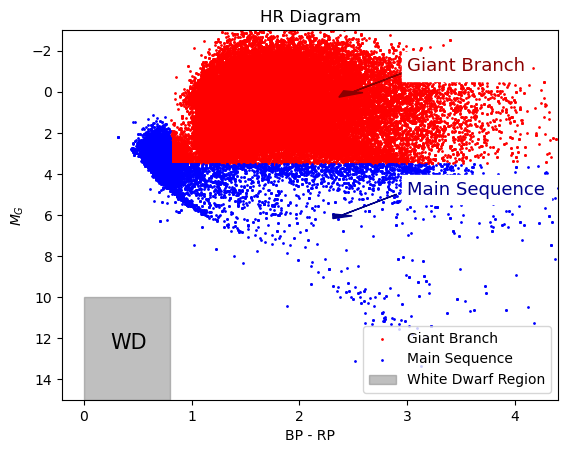

In [1]:
from astropy.io import fits
import numpy as np, matplotlib.pyplot as plt

# open file
hdul = fits.open('APOGEE_stars.fits')

# access data
data = hdul[1].data
colnames = hdul[1].columns.names

#filter data according to given conditions
mask = ((data['STARFLAG'] == 0) & (data['ASPCAPFLAG'] == 0) & (data['SNR'] > 10) & (data['GAIAEDR3_PARALLAX']/data['GAIAEDR3_PARALLAX_ERROR'] > 5)
    & (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) & (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) & (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG'])))
data_good = data[mask]

#get some percentage of data
data_good = data_good[np.random.choice(len(data_good), int(len(data_good)*0.8))]
#80% really oversaturates the giant branch, but using less data doesn't show the main sequence as well

#get x- & y-axis for graph
x_axis = data_good['GAIAEDR3_PHOT_BP_MEAN_MAG'] - data_good['GAIAEDR3_PHOT_RP_MEAN_MAG']
y_axis = data_good['GAIAEDR3_PHOT_G_MEAN_MAG'] + 5*np.log10(data_good['GAIAEDR3_PARALLAX']/1000) + 5

#Giant branch
mask_gb = (x_axis>0.8) & (y_axis<3.5)
x_gb = x_axis[mask_gb]
y_gb = y_axis[mask_gb]

#Main sequence
x_ms = x_axis[~mask_gb]
y_ms = y_axis[~mask_gb]

#White dwarf region
x_wd = [0, 0, 0.8, 0.8]
y_wd = [15, 10, 10, 15]

plt.scatter(x_gb, y_gb, s=1, color='red', label='Giant Branch')
plt.scatter(x_ms, y_ms, s=1, color='blue', label='Main Sequence')
plt.fill(x_wd,y_wd, alpha = 0.5, color='grey', label='White Dwarf Region')
plt.xlim(-0.2,4.4)
plt.ylim(-3,15)
plt.gca().invert_yaxis()
plt.title('HR Diagram')
plt.legend(loc='lower right')
plt.xlabel('BP - RP')
plt.ylabel(r'$M_G$')
plt.text(0.25,12.5,'WD',size=15)
plt.text(3,-1,'Giant Branch',size=13,color='darkred',bbox=dict(facecolor='white',edgecolor='white'))
plt.arrow(3,-1,-0.5,1,head_width=0.2,color='darkred')
plt.text(3,5,'Main Sequence',size=13,color='darkblue',bbox=dict(facecolor='white',edgecolor='white'))
plt.arrow(2.9,5,-0.5,1,head_width=0.2,head_length=0.2,color='darkblue')
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")